# Hospital Queue & Patient Journey EDA

## tl;dr

Notebook này kiểm tra độ tin cậy của dữ liệu vận hành, mô tả wait time, đánh giá SLA/no-show/resource failure và xác định bottleneck trong hành trình **A → B → quay lại A**. Kết luận chỉ có giá trị mô tả đối với dữ liệu live/seeded hiện tại; baseline synthetic không phải bằng chứng nhân quả trong bệnh viện thật.

## Context & Methods

**Business questions.** Bệnh nhân chờ lâu ở đâu, khung giờ/phòng nào tạo backlog, resource failure và emergency insertion đi cùng thay đổi wait time ra sao, và bước nào kéo dài journey.

### Key Assumptions

- Múi giờ báo cáo: `Asia/Ho_Chi_Minh`.
- Operational wait = `service_start - max(ready_at, arrival_time)`; `actual_wait_time` chỉ là fallback.
- SLA demo lấy từ `analytics/config/metrics.yml` và chưa phải cam kết SLA chính thức của bệnh viện.
- Patient token được hash trước khi xuất khỏi tầng extraction.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks': REPO_ROOT = REPO_ROOT.parents[1]
elif REPO_ROOT.name == 'analytics': REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analytics.src.extract import load_tasks
from analytics.src.metrics import prepare_tasks, kpis, journey_summary
from analytics.src.data_quality import profile_tasks

FIGURES = REPO_ROOT / 'analytics' / 'reports' / 'figures'
OUTPUTS = REPO_ROOT / 'analytics' / 'outputs'
FIGURES.mkdir(parents=True, exist_ok=True); OUTPUTS.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
raw, source = load_tasks(prefer_live=True)
tasks = prepare_tasks(raw)
display(Markdown(f'**Source:** `{source}`  \n+**Rows:** {len(tasks):,} · **Columns:** {len(tasks.columns):,}'))

**Source:** `PostgreSQL/ep-falling-recipe-awd1tcj2.c-12.us-east-1.aws.neon.tech/neondb`  
+**Rows:** 136 · **Columns:** 62

## Data — schema, grain và chất lượng

In [2]:
dictionary = pd.DataFrame({
    'column': tasks.columns,
    'dtype': [str(tasks[c].dtype) for c in tasks.columns],
    'missing': [int(tasks[c].isna().sum()) for c in tasks.columns],
    'missing_rate': [float(tasks[c].isna().mean()) for c in tasks.columns],
    'grain_or_meaning': ['task-level field; see Prisma schema and metrics.yml' for _ in tasks.columns],
})
display(dictionary)
dictionary.to_csv(OUTPUTS / 'data_dictionary.csv', index=False)

,column,dtype,missing,missing_rate,grain_or_meaning
0,task_id,object,0,0.000000,task-level field; see Prisma schema and metric...
1,journey_id,object,0,0.000000,task-level field; see Prisma schema and metric...
2,journey_step,object,0,0.000000,task-level field; see Prisma schema and metric...
3,parent_task_id,object,113,0.830882,task-level field; see Prisma schema and metric...
4,depends_on_task_id,object,113,0.830882,task-level field; see Prisma schema and metric...
...,...,...,...,...,...
57,sla_minutes,int64,0,0.000000,task-level field; see Prisma schema and metric...
58,sla_breach,bool,0,0.000000,task-level field; see Prisma schema and metric...
59,event_date,object,104,0.764706,task-level field; see Prisma schema and metric...
60,event_hour,float64,104,0.764706,task-level field; see Prisma schema and metric...


In [3]:
quality_checks, quality_summary = profile_tasks(raw)
display(quality_checks)
quality_checks.to_csv(OUTPUTS / 'data_quality_checks.csv', index=False)
display(Markdown(f"**Business takeaway.** {quality_summary['failed_checks']} / {quality_summary['quality_checks']} checks có failure; ưu tiên các lỗi critical/high trước khi dùng dashboard để ra quyết định."))

,check,failures,rate,severity,note
0,duplicate task_id,0,0.000000,critical,Task grain must be unique.
1,missing task_id,0,0.000000,critical,Primary task identifier is required.
2,missing journey_id,0,0.000000,high,Required analytical dimension.
3,missing task_type,0,0.000000,high,Required analytical dimension.
4,missing service_type,0,0.000000,high,Required analytical dimension.
5,missing clinical_priority,0,0.000000,high,Required analytical dimension.
6,invalid timestamp: checkin_at,0,0.000000,high,Value cannot be parsed as UTC timestamp.
7,invalid timestamp: assigned_at,0,0.000000,high,Value cannot be parsed as UTC timestamp.
8,invalid timestamp: arrival_time,0,0.000000,high,Value cannot be parsed as UTC timestamp.
9,invalid timestamp: ready_at,0,0.000000,high,Value cannot be parsed as UTC timestamp.


**Business takeaway.** 1 / 24 checks có failure; ưu tiên các lỗi critical/high trước khi dùng dashboard để ra quyết định.

## Results — phân phối wait time và SLA

,minutes
count,32.000000
mean,9.668582
std,9.590642
min,0.435133
50%,7.963967
80%,16.476857
90%,19.488802
95%,23.664573
max,42.904650


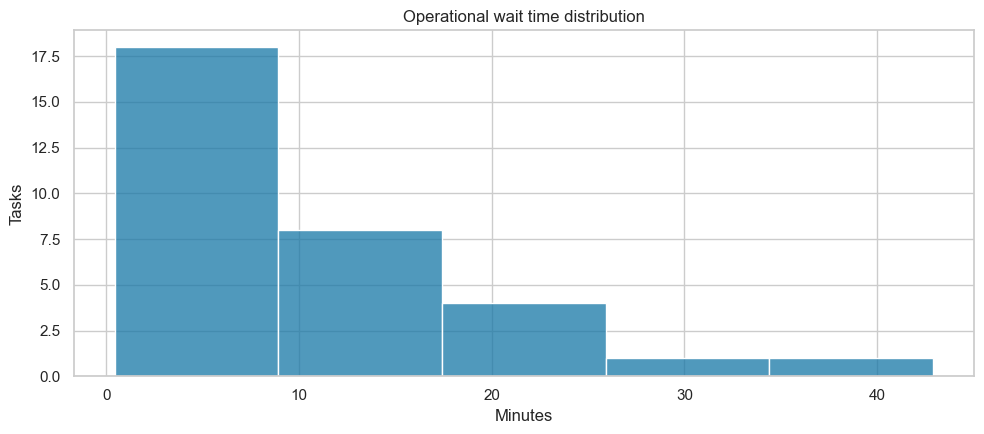

**Business takeaway.** Median là **8.0 phút**, P80 **16.5 phút**, P90 **19.5 phút**. P80/P90 cần được theo dõi thay vì chỉ dùng average vì wait time có đuôi dài.

In [4]:
waits = tasks['operational_wait_minutes'].dropna()
summary = waits.describe(percentiles=[.5,.8,.9,.95]).to_frame('minutes')
display(summary)
fig, ax = plt.subplots(figsize=(10,4.5))
sns.histplot(waits, bins=min(30, max(5, int(np.sqrt(len(waits))))), ax=ax, color='#1677A6')
ax.set(title='Operational wait time distribution', xlabel='Minutes', ylabel='Tasks')
fig.tight_layout(); fig.savefig(FIGURES / 'wait_distribution.png', dpi=160); plt.show()
display(Markdown(f"**Business takeaway.** Median là **{waits.median():.1f} phút**, P80 **{waits.quantile(.8):.1f} phút**, P90 **{waits.quantile(.9):.1f} phút**. P80/P90 cần được theo dõi thay vì chỉ dùng average vì wait time có đuôi dài."))

In [5]:
segments = [c for c in ['room_name','queue_id','service_type','event_hour','clinical_priority'] if c in tasks]
for dimension in segments:
    grouped = tasks.groupby(dimension, dropna=False).agg(tasks=('task_id','nunique'), median_wait=('operational_wait_minutes','median'), p80_wait=('operational_wait_minutes',lambda s:s.quantile(.8)), sla_breach_rate=('sla_breach','mean')).reset_index().sort_values('p80_wait', ascending=False)
    display(Markdown(f'### Wait time theo {dimension}'))
    display(grouped.head(20))
    grouped.to_csv(OUTPUTS / f'wait_by_{dimension}.csv', index=False)
display(Markdown('**Business takeaway.** Các segment có P80 cao đồng thời volume lớn là ứng viên bottleneck; segment mẫu nhỏ cần được xem là tín hiệu điều tra, không phải kết luận vận hành.'))

### Wait time theo room_name

,room_name,tasks,median_wait,p80_wait,sla_breach_rate
15,NaN,20,13.713125,18.297063,0.05
11,Phòng khám Tiêu hóa - Gan mật 304,8,2.304975,3.399260,0.00
14,Phòng khám Tổng quát 101,7,1.608275,2.296700,0.00
9,Phòng khám Thần kinh 202,8,1.659992,1.733337,0.00
8,Phòng khám Tai Mũi Họng 203,29,1.029233,1.029233,0.00
0,Phòng Phân loại Cấp cứu 102,9,0.808517,0.900097,0.00
12,Phòng khám Tiết niệu 402,6,0.656367,0.656367,0.00
10,Phòng khám Tim mạch 201,7,0.435133,0.435133,0.00
1,Phòng khám Cơ Xương Khớp 303,7,NaN,NaN,0.00
2,Phòng khám Da liễu 204,5,NaN,NaN,0.00


### Wait time theo queue_id

,queue_id,tasks,median_wait,p80_wait,sla_breach_rate
16,ULTRASOUND-01,8,15.593442,18.869563,0.0
0,CLINIC-A,10,13.299408,18.627990,0.1
17,XRAY-01,2,11.134383,12.509053,0.0
6,QUEUE-ROOM-GASTRO-304-CLINICAL_CONSULT,8,2.304975,3.399260,0.0
7,QUEUE-ROOM-GENERAL-101-CLINICAL_CONSULT,7,1.608275,2.296700,0.0
8,QUEUE-ROOM-NEURO-202-CLINICAL_CONSULT,8,1.659992,1.733337,0.0
4,QUEUE-ROOM-ENT-203-CLINICAL_CONSULT,29,1.029233,1.029233,0.0
5,QUEUE-ROOM-ER-102-CLINICAL_CONSULT,9,0.808517,0.900097,0.0
15,QUEUE-ROOM-URO-402-CLINICAL_CONSULT,6,0.656367,0.656367,0.0
1,QUEUE-ROOM-CARD-201-CLINICAL_CONSULT,7,0.435133,0.435133,0.0


### Wait time theo service_type

...

### Wait time theo event_hour

,event_hour,tasks,median_wait,p80_wait,sla_breach_rate
8,13.0,1,42.904650,42.904650,1.0
2,3.0,1,26.537883,26.537883,0.0
6,11.0,1,19.659050,19.659050,0.0
12,19.0,2,17.511183,17.778413,0.0
14,21.0,1,17.685333,17.685333,0.0
7,12.0,3,8.843267,16.325517,0.0
16,23.0,1,14.013750,14.013750,0.0
11,18.0,1,14.000750,14.000750,0.0
0,0.0,1,13.425500,13.425500,0.0
1,1.0,2,7.566933,9.825203,0.0


### Wait time theo clinical_priority

,clinical_priority,tasks,median_wait,p80_wait,sla_breach_rate
2,NORMAL,104,7.759083,17.065800,0.009615
3,URGENT,16,11.330717,11.330717,0.000000
0,EMERGENCY,1,NaN,NaN,0.000000
1,NON_URGENT,15,NaN,NaN,0.000000


**Business takeaway.** Các segment có P80 cao đồng thời volume lớn là ứng viên bottleneck; segment mẫu nhỏ cần được xem là tín hiệu điều tra, không phải kết luận vận hành.

## No-show, queue pressure và trạng thái resource

,metric,value
0,No-show rate,0.088235
1,SLA breach rate,0.031250


,queue_length,arrival_rate_15m,avg_service_30m,operational_wait_minutes
queue_length,1.000000,0.101011,0.040429,0.000321
arrival_rate_15m,0.101011,1.000000,-0.033146,-0.099333
avg_service_30m,0.040429,-0.033146,1.000000,0.338701
operational_wait_minutes,0.000321,-0.099333,0.338701,1.000000


C:\Users\TD\AppData\Local\Temp\ipykernel_34196\956281798.py:9: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  fig, ax = plt.subplots(figsize=(8,4.5)); sns.scatterplot(data=plot_data, x='queue_length', y='operational_wait_minutes', hue='resource_failure' if 'resource_failure' in plot_data else None, ax=ax, palette=['#1677A6','#E58245']); fig.tight_layout(); fig.savefig(FIGURES/'queue_vs_wait.png', dpi=160); plt.show()


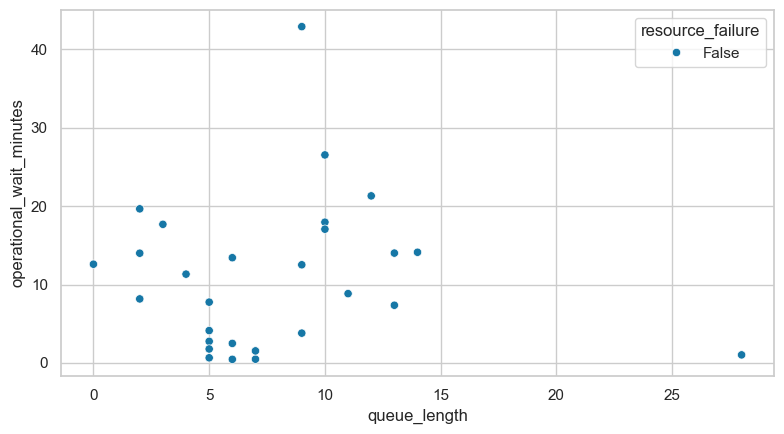

**Business takeaway.** No-show hiện là **8.8%**, SLA breach **3.1%**. Quan hệ queue/resource và wait chỉ là association; cần simulation hoặc thử nghiệm vận hành để kết luận tác động.

In [6]:
no_show = tasks.get('no_show', pd.Series(False, index=tasks.index)).fillna(False).astype(bool).mean()
sla_rate = tasks.loc[tasks['operational_wait_minutes'].notna(), 'sla_breach'].mean()
display(pd.DataFrame({'metric':['No-show rate','SLA breach rate'], 'value':[no_show, sla_rate]}))
relationship_cols = [c for c in ['queue_length','arrival_rate_15m','avg_service_30m','operational_wait_minutes'] if c in tasks]
display(tasks[relationship_cols].corr(numeric_only=True))
if {'queue_length','operational_wait_minutes'}.issubset(tasks):
    plot_data = tasks.dropna(subset=['queue_length','operational_wait_minutes'])
    if len(plot_data) >= 8:
        fig, ax = plt.subplots(figsize=(8,4.5)); sns.scatterplot(data=plot_data, x='queue_length', y='operational_wait_minutes', hue='resource_failure' if 'resource_failure' in plot_data else None, ax=ax, palette=['#1677A6','#E58245']); fig.tight_layout(); fig.savefig(FIGURES/'queue_vs_wait.png', dpi=160); plt.show()
display(Markdown(f'**Business takeaway.** No-show hiện là **{no_show:.1%}**, SLA breach **{sla_rate:.1%}**. Quan hệ queue/resource và wait chỉ là association; cần simulation hoặc thử nghiệm vận hành để kết luận tác động.'))

## Patient journey A → B → quay lại A

In [7]:
journeys = journey_summary(tasks)
display(journeys.describe(include='all'))
step_summary = tasks.groupby('task_type', dropna=False).agg(tasks=('task_id','nunique'), median_wait=('operational_wait_minutes','median'), median_service=('service_duration_minutes','median'), median_result_turnaround=('result_turnaround_minutes','median')).reset_index()
display(step_summary)
step_summary.to_csv(OUTPUTS/'journey_step_summary.csv', index=False)
journeys.to_csv(OUTPUTS/'journey_summary.csv', index=False)
bottleneck = step_summary.sort_values('median_wait', ascending=False).iloc[0]
display(Markdown(f"**Business takeaway.** Bước có median operational wait cao nhất là **{bottleneck['task_type']}** ({bottleneck['median_wait']:.1f} phút). Có **{int(journeys['has_a_b_return'].sum())}** journey đủ A → B → return trong dữ liệu hiện tại."))

,journey_id,journey_completion_minutes,task_count,completed_tasks,has_a_b_return
count,112,16.000000,112.000000,112.000000,112
unique,112,NaN,NaN,NaN,2
top,J-1784385353096-dcd754071e,NaN,NaN,NaN,False
freq,1,NaN,NaN,NaN,106
mean,NaN,14220.231557,1.214286,0.294643,NaN
std,NaN,22214.912746,0.752516,0.855700,NaN
min,NaN,0.834550,1.000000,0.000000,NaN
25%,NaN,11.500808,1.000000,0.000000,NaN
50%,NaN,574.583917,1.000000,0.000000,NaN
75%,NaN,30067.888912,1.000000,0.000000,NaN


,task_type,tasks,median_wait,median_service,median_result_turnaround
0,DIAGNOSTIC_SERVICE,18,8.102542,8.682867,10.176867
1,INITIAL_CONSULT,112,6.148817,8.205917,10.597617
2,RETURN_REVIEW,6,10.141658,6.112650,5.647192


**Business takeaway.** Bước có median operational wait cao nhất là **RETURN_REVIEW** (10.1 phút). Có **6** journey đủ A → B → return trong dữ liệu hiện tại.

## Bottleneck synthesis

In [8]:
room_col = 'room_name' if 'room_name' in tasks and tasks['room_name'].notna().any() else 'queue_id'
bottlenecks = tasks.groupby(room_col, dropna=False).agg(tasks=('task_id','nunique'), median_wait=('operational_wait_minutes','median'), p90_wait=('operational_wait_minutes',lambda s:s.quantile(.9)), sla_breach_rate=('sla_breach','mean'), max_queue=('queue_length','max')).reset_index()
bottlenecks['bottleneck_score'] = bottlenecks['p90_wait'].rank(pct=True) + bottlenecks['sla_breach_rate'].rank(pct=True) + bottlenecks['tasks'].rank(pct=True)
bottlenecks = bottlenecks.sort_values('bottleneck_score', ascending=False)
display(bottlenecks)
bottlenecks.to_csv(OUTPUTS/'bottleneck_ranking.csv', index=False)
display(Markdown('**Business takeaway.** Bottleneck score kết hợp tail wait, breach và volume để ưu tiên điều tra; không dùng score này như quyết định phân bổ nguồn lực tự động.'))

,room_name,tasks,median_wait,p90_wait,sla_breach_rate,max_queue,bottleneck_score
15,NaN,20,13.713125,21.836103,0.05,14.0,2.93750
11,Phòng khám Tiêu hóa - Gan mật 304,8,2.304975,3.764022,0.00,7.0,2.15625
8,Phòng khám Tai Mũi Họng 203,29,1.029233,1.029233,0.00,28.0,2.00000
9,Phòng khám Thần kinh 202,8,1.659992,1.757785,0.00,7.0,1.90625
14,Phòng khám Tổng quát 101,7,1.608275,2.526175,0.00,6.0,1.87500
0,Phòng Phân loại Cấp cứu 102,9,0.808517,0.930623,0.00,4.0,1.75000
10,Phòng khám Tim mạch 201,7,0.435133,0.435133,0.00,4.0,1.25000
12,Phòng khám Tiết niệu 402,6,0.656367,0.656367,0.00,5.0,1.25000
1,Phòng khám Cơ Xương Khớp 303,7,NaN,NaN,0.00,6.0,NaN
2,Phòng khám Da liễu 204,5,NaN,NaN,0.00,4.0,NaN


**Business takeaway.** Bottleneck score kết hợp tail wait, breach và volume để ưu tiên điều tra; không dùng score này như quyết định phân bổ nguồn lực tự động.

## Takeaways

1. Dùng P80/P90 cùng SLA breach để quản trị trải nghiệm đuôi dài.
2. Tách wait tại phòng dịch vụ và wait quay lại review; `RESULT_PENDING` không nên chiếm hard queue.
3. Ưu tiên bottleneck có đồng thời volume, P90 và breach cao.
4. Dữ liệu seeded/synthetic phù hợp demo pipeline; cần timestamp và resource-event thực tế để đánh giá tác động thật.